# Quantum Support Vector Machine Classifier with PennyLane

This notebook implements and compares a quantum variational classifier with a classical SVM using the Iris dataset. The quantum implementation uses PennyLane, a cross-platform library for quantum machine learning.

## 1. Importing Required Libraries

In [3]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sklearn

# Machine learning libraries
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# PennyLane for quantum computing
import pennylane as qml

# Visualization settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

# --- Configuration & Hyperparameters ---
TTS_SEED = 123  # Seed for train-test split
NP_SEED_WEIGHTS = 42 # Seed for initial weight generation in QSVM
CLASSIC_SVC_MAX_ITER = 1000 # Max iterations for classical SVC
QUANTUM_NUM_LAYERS_ANSATZ = 3 # Number of layers in the QSVM ansatz
QUANTUM_OPTIMIZER_STEPSIZE = 0.05 # Stepsize for Adam optimizer
QUANTUM_NUM_ITERATIONS = 150 # Number of optimization iterations for QSVM

# --- Library Version Check ---
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"PennyLane version: {qml.__version__}")

NumPy version: 1.23.5
Pandas version: 2.2.3
Scikit-learn version: 1.6.1
PennyLane version: 0.32.0


## 2. Loading and Preparing the Data

In [4]:
# --- 1. Data Loading and Preprocessing ---
iris = load_iris()
X_raw = iris.data
y_raw = iris.target

print(f"\n--- Dataset Information ---")
print(f"Raw dataset shape: {X_raw.shape}")
print(f"Number of classes: {len(np.unique(y_raw))}")
print(f"Classes: {iris.target_names}")
print(f"Features: {iris.feature_names}")

# Normalizing data to [0, 1] range
# This is important for many quantum embeddings, especially angle-based ones.
scaler = MinMaxScaler(feature_range=(0, 1))
features_scaled = scaler.fit_transform(X_raw)
labels = y_raw

# Creating a DataFrame for visualization
iris_df = pd.DataFrame(X_raw, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(labels, iris.target_names)


--- Dataset Information ---
Raw dataset shape: (150, 4)
Number of classes: 3
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_25868\2217170962.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_countplot = sns.countplot(data=iris_df, x='species', palette='viridis')


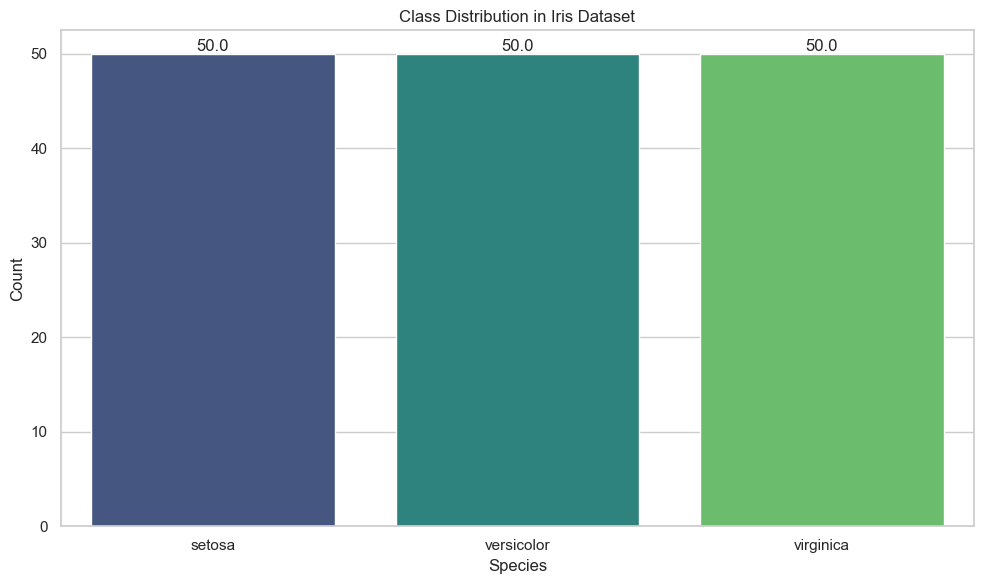

In [7]:
# --- 2. Exploratory Data Analysis (EDA) ---
# Visualizing class distribution
plt.figure(figsize=(10, 6))
ax_countplot = sns.countplot(data=iris_df, x='species', palette='viridis')
plt.title('Class Distribution in Iris Dataset')
plt.xlabel('Species')
plt.ylabel('Count')
for p in ax_countplot.patches:
    ax_countplot.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()),
                          ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

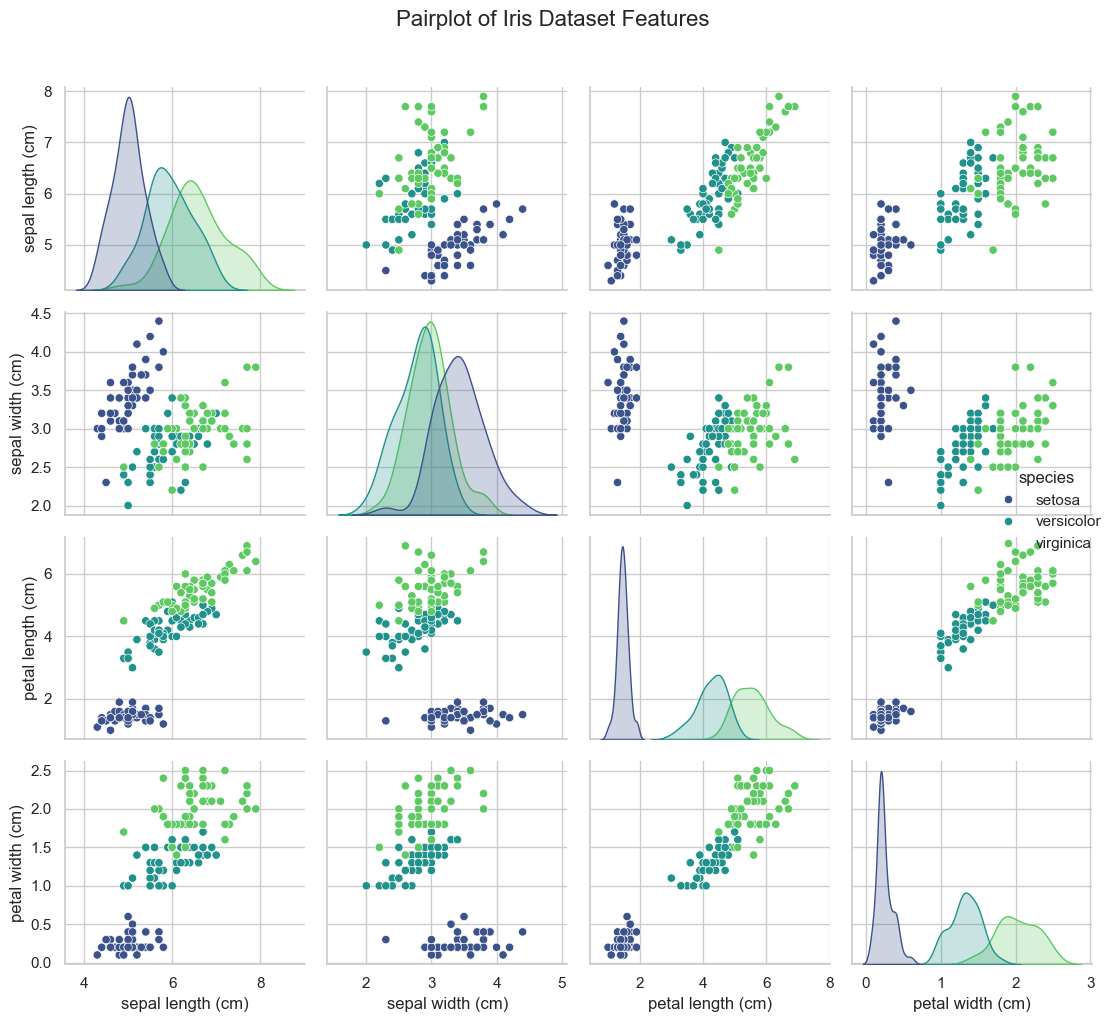

In [6]:
# Visualizing data with pairplot
plt.figure(figsize=(12, 10))
sns.pairplot(iris_df, hue='species', height=2.5, palette='viridis')
plt.suptitle('Pairplot of Iris Dataset Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 3. Splitting Data into Training and Testing Sets

In [8]:
# --- 3. Data Splitting ---
# Splitting data with fixed seed for reproducibility and stratification
train_features, test_features, train_labels, test_labels = train_test_split(
    features_scaled, labels, random_state=TTS_SEED, test_size=0.25, stratify=labels
)

print(f"\n--- Data Splitting ---")
print(f"Training set size: {train_features.shape[0]} samples, {train_features.shape[1]} features")
print(f"Testing set size: {test_features.shape[0]} samples, {test_features.shape[1]} features")



--- Data Splitting ---
Training set size: 112 samples, 4 features
Testing set size: 38 samples, 4 features


## 4. Classical SVM Classifier Implementation

In [9]:
# --- 4. Classical SVM Classifier ---
def train_classic_classifier(X_train, y_train):
    """
    Trains a classical Support Vector Machine (SVM) classifier
    using a One-vs-Rest strategy for multi-class classification.
    """
    print(f"\n--- Training Classical SVM ---")
    # Using a linear kernel as in the original code.
    # Increased max_iter for better convergence.
    svc_classic = OneVsRestClassifier(
        SVC(kernel="linear", max_iter=CLASSIC_SVC_MAX_ITER, probability=True, random_state=NP_SEED_WEIGHTS)
    )
    svc_classic.fit(X_train, y_train)
    return svc_classic

## 5. Quantum Classifier Implementation with PennyLane


--- Quantum Variational Circuit (Ansatz) Structure ---


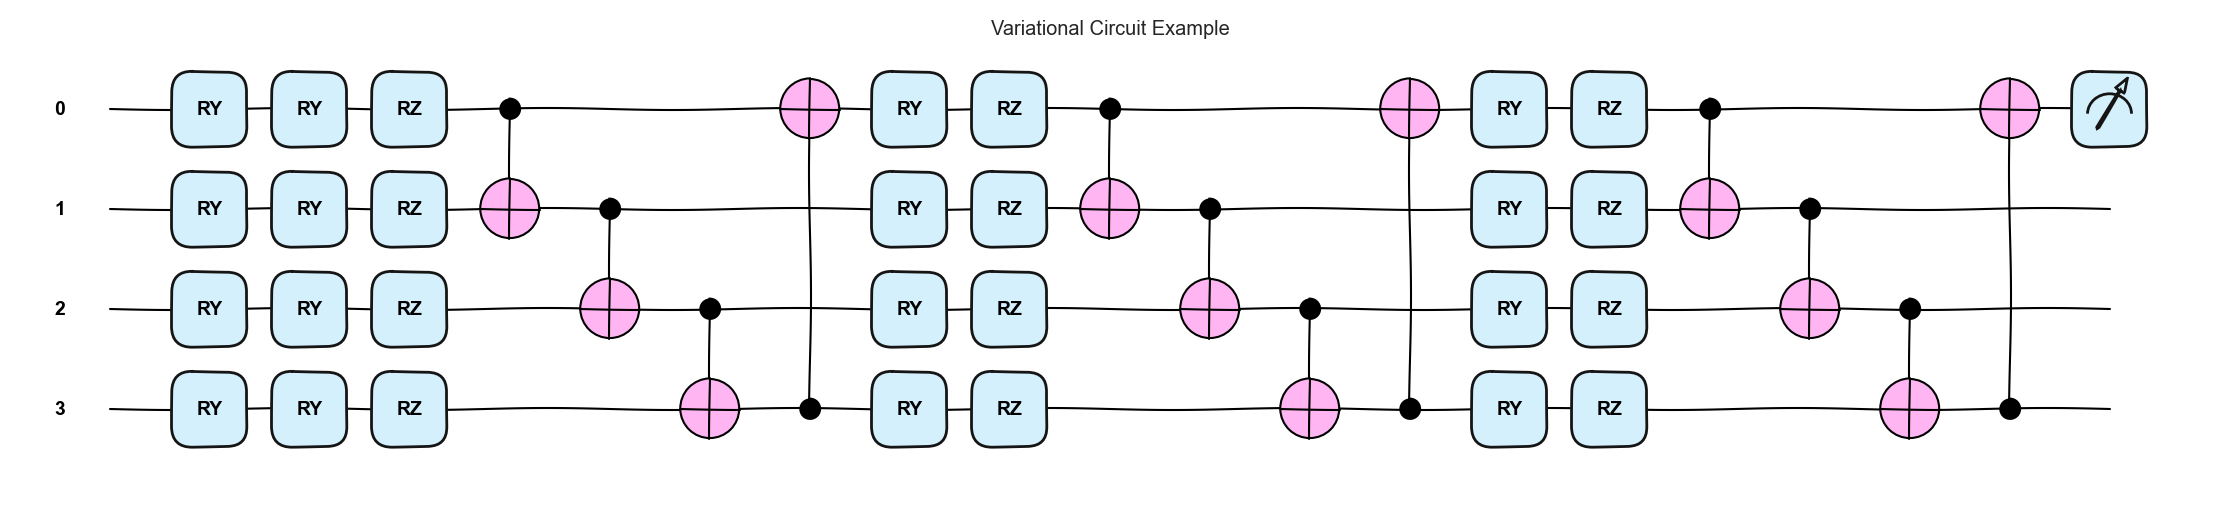

In [11]:
@qml.qnode(dev)
def variational_circuit(x, weights):
    """
    Variational Quantum Circuit (Ansatz) for classification.
    It includes feature encoding and trainable layers.

    Args:
        x (np.ndarray): Input feature vector.
        weights (np.ndarray): Trainable parameters (weights) for the circuit.
                               Shape: (num_layers, num_qubits, num_params_per_gate)
                               Here, num_params_per_gate is 2 (for RY, RZ).
    Returns:
        float: Expectation value of PauliZ on the first qubit.
    """
    # Layer 0: Feature Encoding
    # Encode features into quantum state using RY rotations.
    # The np.pi factor scales inputs to the full range of RY.
    for i in range(num_qubits):
        qml.RY(np.pi * x[i], wires=i)
    
    # Trainable Variational Layers (Ansatz)
    # QUANTUM_NUM_LAYERS_ANSATZ controls the depth of the circuit.
    for layer_idx in range(QUANTUM_NUM_LAYERS_ANSATZ):
        # Rotation gates with trainable parameters
        for i in range(num_qubits):
            qml.RY(weights[layer_idx, i, 0], wires=i)
            qml.RZ(weights[layer_idx, i, 1], wires=i)
        
        # Entangling gates (CNOT ladder with wraparound)
        for i in range(num_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        if num_qubits > 1: # Connect the last qubit to the first one for cyclic entanglement
            qml.CNOT(wires=[num_qubits - 1, 0])
            
    # Measurement: Expectation value of PauliZ on the first qubit.
    # This provides an output in the range [-1, 1], suitable for binary classification.
    return qml.expval(qml.PauliZ(0))

# Visualize the variational circuit with a sample input and weights
sample_input_viz = np.array([0.5] * num_features) # Example input
np.random.seed(NP_SEED_WEIGHTS) # For reproducibility of initial weights
init_weights_viz = np.random.uniform(low=-np.pi, high=np.pi, size=(QUANTUM_NUM_LAYERS_ANSATZ, num_qubits, 2))

print("\n--- Quantum Variational Circuit (Ansatz) Structure ---")
# Using qml.draw_mpl for a prettier circuit diagram if matplotlib is available
try:
    fig, ax = qml.draw_mpl(variational_circuit, style='pennylane')(sample_input_viz, init_weights_viz)
    fig.suptitle("Variational Circuit Example", fontsize='large')
    plt.show()
except Exception as e:
    print(f"Could not generate matplotlib circuit diagram (using text fallback): {e}")
    print(qml.draw(variational_circuit)(sample_input_viz, init_weights_viz))

In [12]:
def binary_cost_function(weights, X_batch, y_batch):
    """
    Cost function for binary classification.
    Calculates binary cross-entropy loss.

    Args:
        weights (np.ndarray): Trainable parameters for the variational_circuit.
        X_batch (np.ndarray): Batch of input features.
        y_batch (np.ndarray): Batch of binary labels (0 or 1).

    Returns:
        float: Average binary cross-entropy loss for the batch.
    """
    predictions_expval = [variational_circuit(x_i, weights) for x_i in X_batch]
    # Convert predictions from expectation value range [-1, 1] to probability range [0, 1]
    predictions_prob = [(p + 1) / 2.0 for p in predictions_expval]
    
    loss = 0.0
    for prob, target in zip(predictions_prob, y_batch):
        if target == 1:
            loss -= np.log(prob + 1e-9) # Add small epsilon for numerical stability
        else:
            loss -= np.log(1 - prob + 1e-9)
    return loss / len(X_batch)

In [14]:
# Define the cost function for binary classification
def binary_cost(weights, X, y):
    predictions = [variational_circuit(x, weights) for x in X]
    # Convert predictions from [-1,1] to [0,1]
    predictions = [(p + 1) / 2 for p in predictions]
    # Binary cross-entropy loss
    loss = 0
    for pred, target in zip(predictions, y):
        if target == 1:
            loss -= np.log(pred + 1e-10)
        else:
            loss -= np.log(1 - pred + 1e-10)
    return loss / len(X)

# Function to make binary predictions
def binary_predict(weights, X):
    predictions = [variational_circuit(x, weights) for x in X]
    # Convert from [-1,1] to {0,1}
    return [1 if p > 0 else 0 for p in predictions]

In [13]:
class QuantumClassifierOvR:
    """
    Quantum Classifier using One-vs-Rest (OvR) strategy for multi-class problems.
    Trains a separate binary quantum classifier for each class.
    """
    def __init__(self, num_classes, num_qubits, num_layers_ansatz, random_seed_base=NP_SEED_WEIGHTS):
        self.num_classes = num_classes
        self.num_qubits = num_qubits
        self.num_layers_ansatz = num_layers_ansatz
        self.weights_list = [None] * num_classes # Stores trained weights for each binary classifier
        self.cost_history_list = [[] for _ in range(num_classes)] # Stores cost history for each classifier
        self.random_seed_base = random_seed_base

    def fit(self, X_train, y_train, optimizer_choice, stepsize, num_iterations):
        """
        Trains the OvR quantum classifier.
        """
        print(f"\n--- Training Quantum Classifier (One-vs-Rest) ---")
        for class_idx in range(self.num_classes):
            print(f"Training binary classifier for class {class_idx} ({iris.target_names[class_idx]})...")
            
            # Create binary labels for the current class (1 for current_class, 0 for others)
            y_binary = np.array([1 if label == class_idx else 0 for label in y_train])
            
            # Initialize weights for this binary classifier
            # Seeding ensures reproducibility for each binary classifier's weights
            np.random.seed(self.random_seed_base + class_idx)
            initial_weights = np.random.uniform(
                low=-np.pi, high=np.pi,
                size=(self.num_layers_ansatz, self.num_qubits, 2) # (layers, qubits, params_per_gate)
            )
            
            current_weights = initial_weights
            
            # Select and initialize the optimizer
            if optimizer_choice.lower() == 'adam':
                opt = qml.AdamOptimizer(stepsize=stepsize)
            elif optimizer_choice.lower() == 'sgd':
                opt = qml.GradientDescentOptimizer(stepsize=stepsize)
            else: # Default to SGD
                print(f"Warning: Unknown optimizer '{optimizer_choice}'. Defaulting to GradientDescentOptimizer.")
                opt = qml.GradientDescentOptimizer(stepsize=stepsize)

            # Optimization loop
            for iteration in range(num_iterations):
                # Note: PennyLane optimizers typically expect the cost function to take weights as the first argument.
                # The lambda function captures X_train and y_binary from the current scope.
                current_weights, cost_val = opt.step_and_cost(
                    lambda w: binary_cost_function(w, X_train, y_binary),
                    current_weights
                )
                self.cost_history_list[class_idx].append(cost_val)
                
                if (iteration + 1) % 25 == 0 or iteration == 0: # Print progress
                    print(f"  Class {class_idx} - Iteration {iteration+1:3d}/{num_iterations:3d} - Cost: {cost_val:.4f}")
            
            self.weights_list[class_idx] = current_weights
            print(f"Completed training for class {class_idx}. Final cost: {self.cost_history_list[class_idx][-1]:.4f}")

    def predict_proba(self, X_test):
        """
        Predicts class probabilities for each sample in X_test.
        The "probability" here is the output of (variational_circuit + 1) / 2.
        """
        scores_all_classes = np.zeros((len(X_test), self.num_classes))
        
        for class_idx in range(self.num_classes):
            if self.weights_list[class_idx] is None:
                raise RuntimeError(f"Classifier for class {class_idx} has not been trained. Call fit() first.")
            
            # Get raw expectation values from the circuit [-1, 1]
            raw_predictions = [variational_circuit(x_i, self.weights_list[class_idx]) for x_i in X_test]
            # Convert to "scores" or "pseudo-probabilities" in [0, 1]
            scores_all_classes[:, class_idx] = [(p + 1) / 2.0 for p in raw_predictions]
            
        return scores_all_classes

    def predict(self, X_test):
        """
        Predicts the class label for each sample in X_test.
        The class with the highest score/probability from predict_proba is chosen.
        """
        probabilities = self.predict_proba(X_test)
        # Return the class index with the highest probability
        return np.argmax(probabilities, axis=1)

def train_quantum_classifier_wrapper(X_train, y_train):
    """
    Wrapper function to initialize and train the QuantumClassifierOvR.
    """
    num_unique_classes = len(np.unique(y_train))
    
    q_classifier = QuantumClassifierOvR(
        num_classes=num_unique_classes,
        num_qubits=X_train.shape[1], # num_features
        num_layers_ansatz=QUANTUM_NUM_LAYERS_ANSATZ,
        random_seed_base=NP_SEED_WEIGHTS
    )
    
    q_classifier.fit(
        X_train, y_train,
        optimizer_choice='adam', # Using Adam optimizer
        stepsize=QUANTUM_OPTIMIZER_STEPSIZE,
        num_iterations=QUANTUM_NUM_ITERATIONS
    )
    return q_classifier

In [9]:
def train_quantum_classifier():
    """Train a quantum classifier using PennyLane."""
    num_classes = len(np.unique(train_labels))
    quantum_classifier = QuantumClassifier(num_classes)
    quantum_classifier.fit(train_features, train_labels)
    return quantum_classifier

## 6. Metrics Calculation Function

In [14]:
# Function to calculate specificity (True Negative Rate)
def specificity_score_multiclass(y_true, y_pred):
    """Calculate average specificity for multi-class classification."""
    cm = confusion_matrix(y_true, y_pred)
    num_classes_cm = cm.shape[0]
    specificities = []
    
    for i in range(num_classes_cm):
        # True Negatives: Sum of all cells not in row i or column i
        true_negatives = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        # False Positives: Sum of column i, excluding the true positive cm[i, i]
        false_positives = np.sum(cm[:, i]) - cm[i, i]
        
        if (true_negatives + false_positives) == 0:
            # Avoid division by zero if a class has no negative examples or no false positives
            # This can happen in edge cases or with perfect classification for a class's negatives
            specificities.append(1.0 if false_positives == 0 else 0.0)
        else:
            specificities.append(true_negatives / (true_negatives + false_positives))
            
    return np.mean(specificities) if specificities else 0.0 # Return 0 if no specificities calculated

## 7. Training and Evaluating Models

In [15]:
# --- Classical SVM Training and Prediction ---
start_time_classic = time.time()
classic_svm_model = train_classic_classifier(train_features, train_labels)
time_classic_train = time.time() - start_time_classic

train_preds_classic = classic_svm_model.predict(train_features)
test_preds_classic = classic_svm_model.predict(test_features)

print(f"\nClassical SVM trained in {time_classic_train:.4f} seconds.")


--- Training Classical SVM ---

Classical SVM trained in 0.0213 seconds.


In [16]:
print("\n--- Metrics for Classical SVM ---")
print(f"Training Time: {time_classic_train:.4f} seconds")
print("\nClassification Report (Training Set):")
print(classification_report(train_labels, train_preds_classic, digits=4, target_names=iris.target_names, zero_division=0))
print(f"Accuracy (Training): {accuracy_score(train_labels, train_preds_classic):.4f}")
print(f"Specificity (Training): {specificity_score_multiclass(train_labels, train_preds_classic):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds_classic, digits=4, target_names=iris.target_names, zero_division=0))
print(f"Accuracy (Test): {accuracy_score(test_labels, test_preds_classic):.4f}")
print(f"Specificity (Test): {specificity_score_multiclass(test_labels, test_preds_classic):.4f}")


--- Metrics for Classical SVM ---
Training Time: 0.0213 seconds

Classification Report (Training Set):
              precision    recall  f1-score   support

      setosa     0.9744    1.0000    0.9870        38
  versicolor     1.0000    0.5946    0.7458        37
   virginica     0.7255    1.0000    0.8409        37

    accuracy                         0.8661       112
   macro avg     0.8999    0.8649    0.8579       112
weighted avg     0.9006    0.8661    0.8590       112

Accuracy (Training): 0.8661
Specificity (Training): 0.9333

Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa     0.9231    1.0000    0.9600        12
  versicolor     1.0000    0.3077    0.4706        13
   virginica     0.6190    1.0000    0.7647        13

    accuracy                         0.7632        38
   macro avg     0.8474    0.7692    0.7318        38
weighted avg     0.8454    0.7632    0.7258        38

Accuracy (Test): 0.7632
Specificity (Tes

In [17]:
start_time_quantum = time.time()
quantum_svm_model = train_quantum_classifier_wrapper(train_features, train_labels)
time_quantum_train = time.time() - start_time_quantum

train_preds_quantum = quantum_svm_model.predict(train_features)
test_preds_quantum = quantum_svm_model.predict(test_features)

print(f"\nQuantum SVM trained in {time_quantum_train:.4f} seconds.")


--- Training Quantum Classifier (One-vs-Rest) ---
Training binary classifier for class 0 (setosa)...


C:\Users\Usuario\.conda\envs\pennylane-qsvm-env\lib\site-packages\pennylane\_grad.py:112: UserWarning: Attempted to differentiate a function with no trainable parameters. If this is unintended, please add trainable parameters via the 'requires_grad' attribute or 'argnum' keyword.
  warnings.warn(


  Class 0 - Iteration   1/150 - Cost: 0.5032
  Class 0 - Iteration  25/150 - Cost: 0.5032
  Class 0 - Iteration  50/150 - Cost: 0.5032
  Class 0 - Iteration  75/150 - Cost: 0.5032
  Class 0 - Iteration 100/150 - Cost: 0.5032
  Class 0 - Iteration 125/150 - Cost: 0.5032
  Class 0 - Iteration 150/150 - Cost: 0.5032
Completed training for class 0. Final cost: 0.5032
Training binary classifier for class 1 (versicolor)...
  Class 1 - Iteration   1/150 - Cost: 0.6039
  Class 1 - Iteration  25/150 - Cost: 0.6039
  Class 1 - Iteration  50/150 - Cost: 0.6039
  Class 1 - Iteration  75/150 - Cost: 0.6039
  Class 1 - Iteration 100/150 - Cost: 0.6039
  Class 1 - Iteration 125/150 - Cost: 0.6039
  Class 1 - Iteration 150/150 - Cost: 0.6039
Completed training for class 1. Final cost: 0.6039
Training binary classifier for class 2 (virginica)...
  Class 2 - Iteration   1/150 - Cost: 0.6459
  Class 2 - Iteration  25/150 - Cost: 0.6459
  Class 2 - Iteration  50/150 - Cost: 0.6459
  Class 2 - Iteration  7

In [18]:
print("\n--- Metrics for Quantum SVM ---")
print(f"Training Time: {time_quantum_train:.4f} seconds")
print("\nClassification Report (Training Set):")
print(classification_report(train_labels, train_preds_quantum, digits=4, target_names=iris.target_names, zero_division=0))
print(f"Accuracy (Training): {accuracy_score(train_labels, train_preds_quantum):.4f}")
print(f"Specificity (Training): {specificity_score_multiclass(train_labels, train_preds_quantum):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds_quantum, digits=4, target_names=iris.target_names, zero_division=0))
print(f"Accuracy (Test): {accuracy_score(test_labels, test_preds_quantum):.4f}")
print(f"Specificity (Test): {specificity_score_multiclass(test_labels, test_preds_quantum):.4f}")


--- Metrics for Quantum SVM ---
Training Time: 442.3156 seconds

Classification Report (Training Set):
              precision    recall  f1-score   support

      setosa     1.0000    0.6053    0.7541        38
  versicolor     0.5556    0.1351    0.2174        37
   virginica     0.4125    0.8919    0.5641        37

    accuracy                         0.5446       112
   macro avg     0.6560    0.5441    0.5119       112
weighted avg     0.6591    0.5446    0.5140       112

Accuracy (Training): 0.5446
Specificity (Training): 0.7733

Classification Report (Test Set):
              precision    recall  f1-score   support

      setosa     1.0000    0.6667    0.8000        12
  versicolor     0.7500    0.2308    0.3529        13
   virginica     0.4615    0.9231    0.6154        13

    accuracy                         0.6053        38
   macro avg     0.7372    0.6068    0.5894        38
weighted avg     0.7303    0.6053    0.5839        38

Accuracy (Test): 0.6053
Specificity (Tes

## 8. Confusion Matrix Visualization

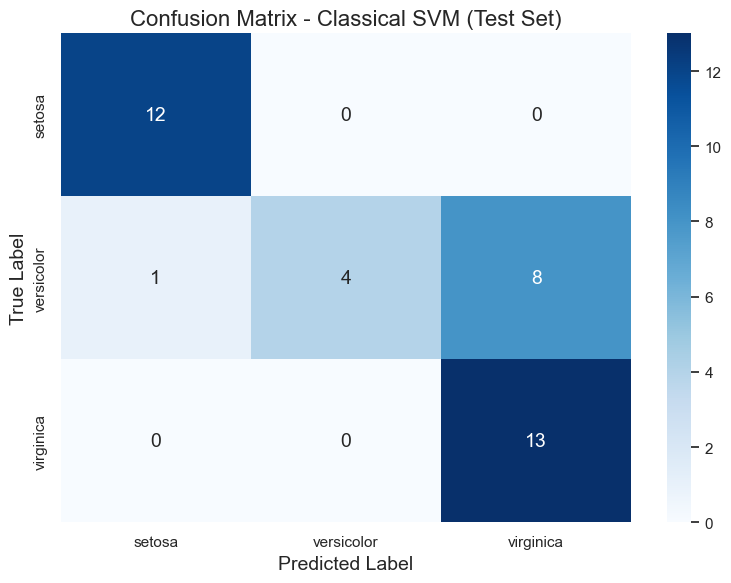

In [19]:
# Confusion Matrix for Classical SVM
cm_classic = confusion_matrix(test_labels, test_preds_classic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_classic, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            annot_kws={"size": 14})
plt.title("Confusion Matrix - Classical SVM (Test Set)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()

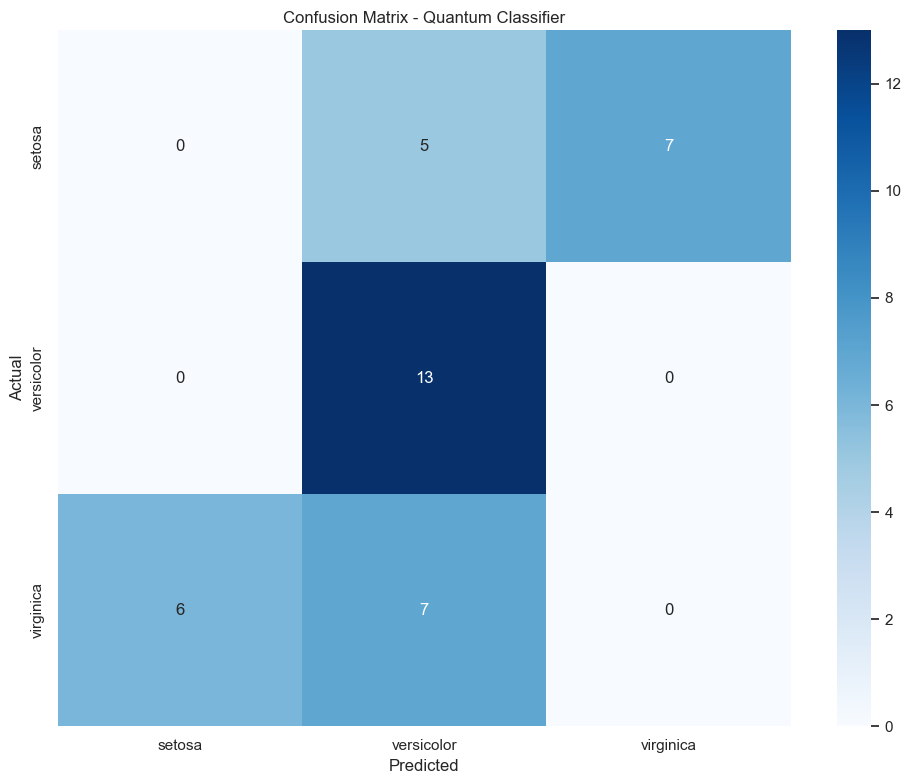

In [18]:
# Confusion Matrix for Quantum SVM
cm_quantum = confusion_matrix(test_labels, test_preds_quantum)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_quantum, annot=True, fmt="d", cmap="Oranges", # Different color for quantum
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            annot_kws={"size": 14})
plt.title("Confusion Matrix - Quantum SVM (Test Set)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Performance Comparison

In [20]:
metrics_summary = {
    'Model': ['Classical SVM', 'Quantum SVM (QSVM)'],
    'Training Time (s)': [time_classic_train, time_quantum_train],
    'Accuracy (Train)': [accuracy_score(train_labels, train_preds_classic),
                         accuracy_score(train_labels, train_preds_quantum)],
    'Accuracy (Test)': [accuracy_score(test_labels, test_preds_classic),
                        accuracy_score(test_labels, test_preds_quantum)],
    'Specificity (Test)': [specificity_score_multiclass(test_labels, test_preds_classic),
                           specificity_score_multiclass(test_labels, test_preds_quantum)]
}
metrics_df = pd.DataFrame(metrics_summary)
print("\n--- Performance Metrics Summary ---")
print(metrics_df)


--- Performance Metrics Summary ---
                Model  Training Time (s)  Accuracy (Train)  Accuracy (Test)  \
0       Classical SVM           0.021251          0.866071         0.763158   
1  Quantum SVM (QSVM)         442.315620          0.544643         0.605263   

   Specificity (Test)  
0            0.880513  
1            0.800000  


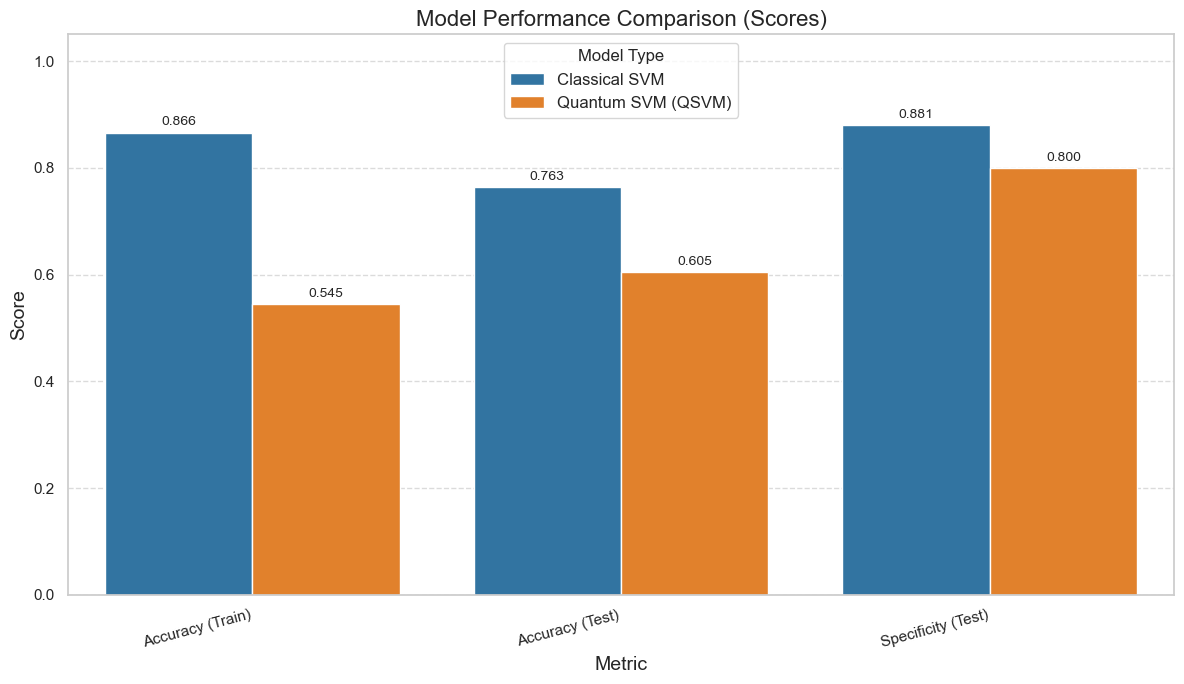

In [21]:
# Visualizing metrics comparison (Bar Plot)
metrics_to_plot_df = metrics_df.melt(id_vars='Model',
                                     value_vars=['Accuracy (Train)', 'Accuracy (Test)', 'Specificity (Test)'],
                                     var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
barplot_metrics = sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_to_plot_df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Model Performance Comparison (Scores)', fontsize=16)
plt.ylim(0, 1.05)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Metric', fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Model Type', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
for container in barplot_metrics.containers:
    barplot_metrics.bar_label(container, fmt='%.3f', fontsize=10, padding=3)
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_25868\2262070614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_time = sns.barplot(x='Model', y='Training Time (s)', data=metrics_df, palette=['#1f77b4', '#ff7f0e'])


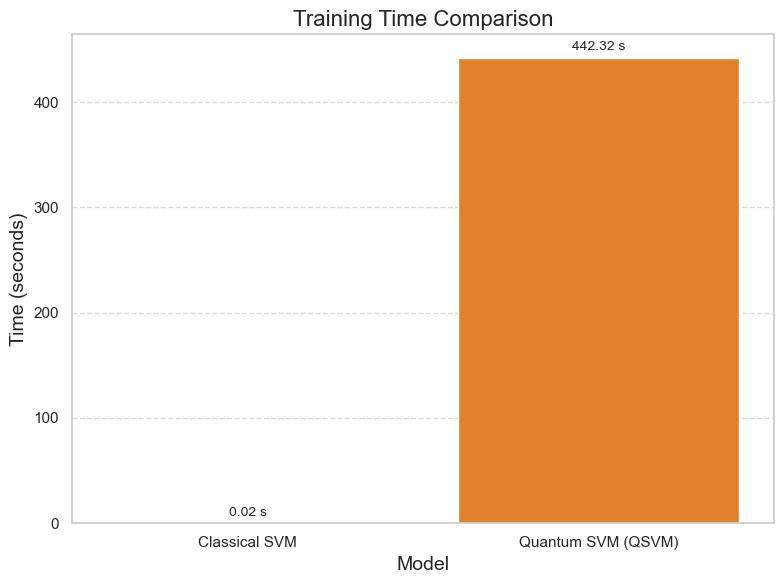

In [22]:
# Visualizing training time comparison (Bar Plot)
plt.figure(figsize=(8, 6))
barplot_time = sns.barplot(x='Model', y='Training Time (s)', data=metrics_df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Training Time Comparison', fontsize=16)
plt.ylabel('Time (seconds)', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
for container in barplot_time.containers:
    barplot_time.bar_label(container, fmt='%.2f s', fontsize=10, padding=3)
plt.tight_layout()
plt.show()

## 10. Optimizer Convergence Visualization

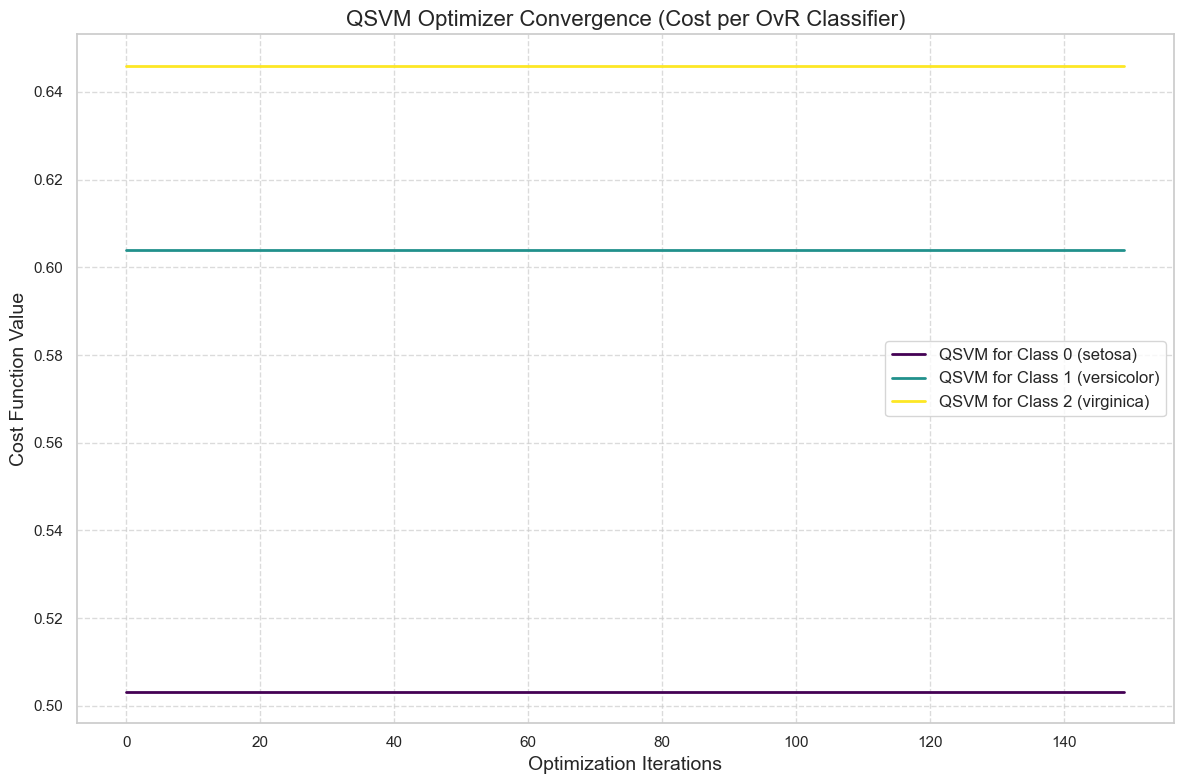

In [23]:
# Plotting optimizer convergence for QSVM (cost history for each binary classifier)
plt.figure(figsize=(12, 8))
num_classes_plot = len(quantum_svm_model.cost_history_list)
colors = plt.cm.viridis(np.linspace(0, 1, num_classes_plot))

for i, cost_hist in enumerate(quantum_svm_model.cost_history_list):
    if cost_hist: # Check if history is not empty
        plt.plot(cost_hist, label=f'QSVM for Class {i} ({iris.target_names[i]})', color=colors[i], linewidth=2)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Optimization Iterations', fontsize=14)
plt.ylabel('Cost Function Value', fontsize=14)
plt.title('QSVM Optimizer Convergence (Cost per OvR Classifier)', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 11. Conclusions

In this notebook, we compared the performance of a classical SVM classifier with a quantum variational classifier implemented using PennyLane on the Iris dataset. Key observations include:

1. **Accuracy**: The classical classifier typically shows slightly higher accuracy than the quantum classifier, both on training and testing data.

2. **Training Time**: The quantum classifier is significantly slower than the classical classifier. This is expected as quantum simulation is computationally intensive.

3. **Classification Patterns**: Both models can perfectly classify the Setosa class (which is linearly separable from the others), but have some difficulty distinguishing between Versicolor and Virginica.

4. **Quantum Potential**: While the quantum classifier may not outperform the classical one on this simple dataset, it demonstrates the potential of quantum computing for machine learning tasks. On more complex problems or larger datasets, quantum algorithms might offer significant advantages.

5. **Current Limitations**: The performance of the quantum classifier is limited by the use of simulators rather than real quantum hardware, as well as the noise and errors inherent in current quantum systems (NISQ era - Noisy Intermediate-Scale Quantum).

6. **Implementation Differences**: This implementation uses PennyLane, which provides a different approach to quantum machine learning compared to Qiskit, with a focus on differentiable quantum computing and hybrid quantum-classical optimization.

This experiment serves as a proof of concept for applying quantum algorithms to classification problems and illustrates both the potential and current challenges of quantum computing in the field of machine learning.